In [11]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append(r'../') # Add this line at the beginner of each notebook to be able to load local functions 
import src.features.EL_data as eld

In [12]:
import xarray as xr
import pandas as pd
import numpy as np
import warnings
import cftime

In [19]:
def load_el_data(csv_path, csv_file, instr, year):
    ladcp_list = eld.get_bodc_files_from_metadata(csv_path, csv_file, instr, year)
    
    # --- Combine all files using open_mfdataset ---
    if instr == 'ladcp':
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UserWarning)
            
            ds = xr.open_mfdataset(
                ladcp_list,
                preprocess=eld.preprocess_ladcp_file,
                combine='nested',          # Use nested combination
                concat_dim='INSTANCE',     # Concatenate along the single 'INSTANCE' dimension
                join='outer',              # Use 'outer' join for the varying 'MAXZ' dimension
                decode_times=True,         # We handle time decoding manually in preprocess
                data_vars='all'
            )
    return ds

In [20]:
csv_path = 'C:/Users/sa07kb/Projects/Rockall_Trough_Transports/data/raw/UK_OSNAP/'
csv_file = 'bodc_series_metadata_summary.csv'
instr = 'ladcp'
year = 2022

ds = load_el_data(csv_path, csv_file, instr, year)
ds



<xarray.Dataset> Size: 789kB
Dimensions:                 (INSTANCE: 43, REFMAX: 5, MAXZ: 375, TIME: 43)
Coordinates:
  * TIME                    (TIME) datetime64[ns] 344B 2022-07-01T21:12:18.00...
  * MAXZ                    (MAXZ) int64 3kB 1 2 3 4 5 6 ... 371 372 373 374 375
    LATITUDE                (INSTANCE) float64 344B dask.array<chunksize=(1,), meta=np.ndarray>
    LONGITUDE               (INSTANCE) float64 344B dask.array<chunksize=(1,), meta=np.ndarray>
    DEPTH                   (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
Dimensions without coordinates: INSTANCE, REFMAX
Data variables: (12/18)
    SDN_CRUISE              (INSTANCE) |S80 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    crs                     (INSTANCE) int32 172B 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    SDN_EDMO_CODE           (INSTANCE) int32 172B dask.array<chunksize=(1,), meta=np.ndarray>
    SDN_STATION             (INSTANCE) |S80 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    SDN_LOCAL_CDI_ID        (INSTANCE) |S80 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    SDN_XLINK               (INSTANCE, REFMAX) |S299 64kB dask.array<chunksize=(1, 5), meta=np.ndarray>
    ...                      ...
    ERRVLDCP_SEADATANET_QC  (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
    ERRVLDCP                (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
    LCEWLW01_SEADATANET_QC  (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
    LCEWLW01                (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
    LCNSLW01_SEADATANET_QC  (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
    LCNSLW01                (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
Attributes:
    date_update:  2025-08-15T01:01:44+0100
    comment:      
    Conventions:  SeaDataNet_1.0 CF-1.6
    featureType:  profile
    title:        SeaDataNet NETCDF PROFILE Climate Forecast 1.6 - GENERATED ...

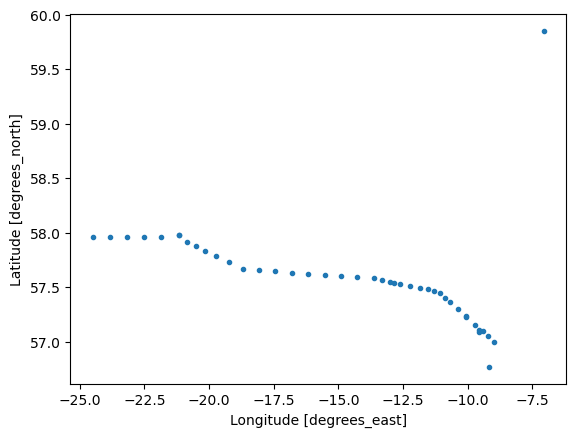

In [30]:
ds.LCNSLW01.LONGITUDE.plot.line('.', y='LATITUDE')